In [1]:
from datasets import load_dataset
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
import random
import io


In [2]:
from datasets import load_dataset

dataset = load_dataset("hf-vision/chest-xray-pneumonia")
print(f"Train: {len(dataset['train']):,}")
print(f"Test: {len(dataset['test']):,}")

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


README.md:   0%|          | 0.00/2.06k [00:00<?, ?B/s]

data/train-00000-of-00007.parquet: reconstructing file:   0%|          |  0.00B /  446MB            

data/train-00000-of-00007.parquet: downloading bytes:           |  0.00B            

data/train-00001-of-00007.parquet: reconstructing file:   0%|          |  0.00B /  385MB            

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5216 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/16 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/624 [00:00<?, ? examples/s]

Train: 5,216
Test: 624


Viewing single image...



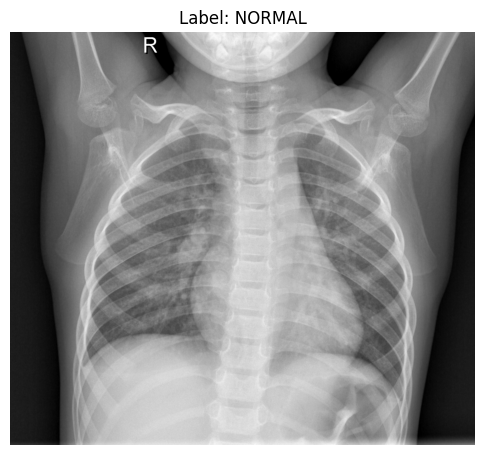

Image size: (2090, 1858)
Image mode: L
Label: NORMAL


In [3]:

print("Viewing single image...\n")

sample = dataset['train'][0]
image = sample['image']
label = sample['label']

label_text = "PNEUMONIA" if label == 1 else "NORMAL"

plt.figure(figsize=(6, 6))
plt.imshow(image, cmap='gray')
plt.title(f"Label: {label_text}")
plt.axis('off')
plt.show()

print(f"Image size: {image.size}")
print(f"Image mode: {image.mode}")
print(f"Label: {label_text}")

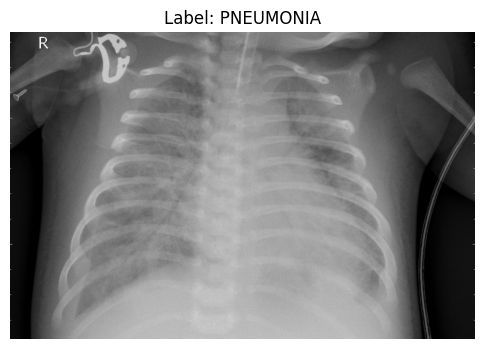

In [4]:
# looking and pneumonia data
for i in range(len(dataset['train'])):
    sample = dataset['train'][i]
    if sample['label'] == 1:
        image = sample['image']
        plt.figure(figsize=(6, 6))
        plt.imshow(image, cmap='gray')
        plt.title("Label: PNEUMONIA")
        plt.axis('off')
        plt.show()
        break

sample number

In [5]:
n_train = len(dataset["train"])
n_test = len(dataset["test"])
total = n_train + n_test

print(f"Train samples: {n_train:,}")
print(f"Test samples : {n_test:,}")
print(f"Total samples: {total:,}")

Train samples: 5,216
Test samples : 624
Total samples: 5,840


In [6]:
label_feature = dataset["train"].features["label"]
print("Target variable:", "label")
print("Type            :", label_feature)
print("Number of classes:", label_feature.num_classes)
print("Class names      :", label_feature.names)

Target variable: label
Type            : ClassLabel(names=['NORMAL', 'PNEUMONIA'])
Number of classes: 2
Class names      : ['NORMAL', 'PNEUMONIA']


Class distribution

In [7]:
import pandas as pd


In [8]:
def class_counts(split):
    labels = dataset[split]["label"]
    counts = Counter(labels)
    return {dataset["train"].features["label"].int2str(k): v for k, v in counts.items()}

train_counts = class_counts("train")
test_counts = class_counts("test")

dist_df = pd.DataFrame({"train": train_counts, "test": test_counts}).fillna(0).astype(int)
dist_df["train_pct"] = (dist_df["train"] / dist_df["train"].sum() * 100).round(1)
dist_df["test_pct"] = (dist_df["test"] / dist_df["test"].sum() * 100).round(1)
dist_df

,train,test,train_pct,test_pct
NORMAL,1341,234,25.7,37.5
PNEUMONIA,3875,390,74.3,62.5


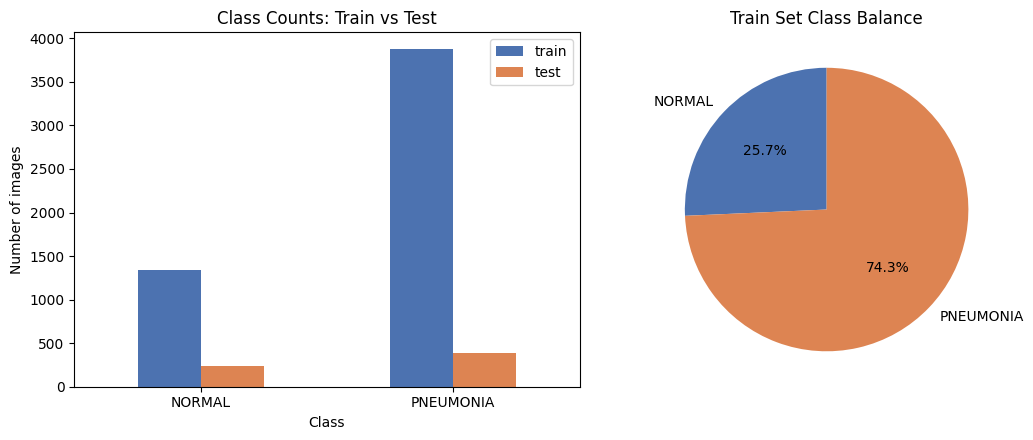

Note: the dataset is class-imbalanced — PNEUMONIA outnumbers NORMAL in the
training set, which is worth accounting for later (e.g. class weights, or
reporting macro/per-class metrics rather than relying on raw accuracy).


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

dist_df[["train", "test"]].plot(kind="bar", ax=axes[0], color=["#4C72B0", "#DD8452"])
axes[0].set_title("Class Counts: Train vs Test")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Number of images")
axes[0].tick_params(axis="x", rotation=0)

axes[1].pie(dist_df["train"], labels=dist_df.index, autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=90)
axes[1].set_title("Train Set Class Balance")

plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()

print("Note: the dataset is class-imbalanced — PNEUMONIA outnumbers NORMAL in the")
print("training set, which is worth accounting for later (e.g. class weights, or")
print("reporting macro/per-class metrics rather than relying on raw accuracy).")

Visualization

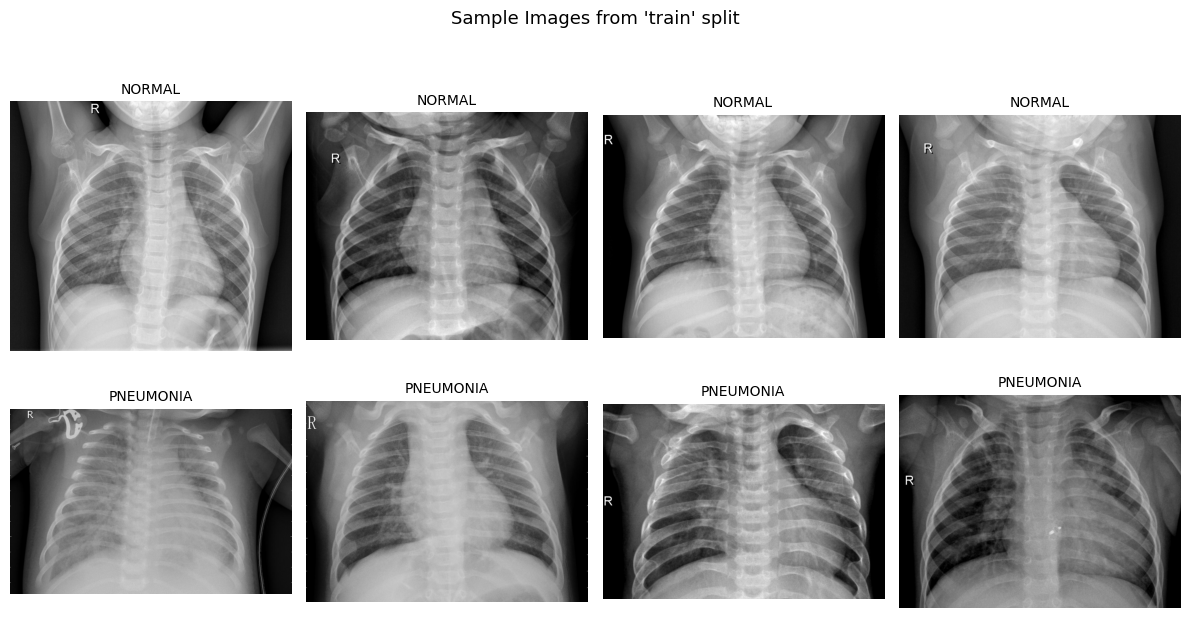

In [10]:
def show_sample_grid(split="train", n_per_class=4):
    fig, axes = plt.subplots(2, n_per_class, figsize=(3 * n_per_class, 6.5))

    for class_id, class_name in enumerate(dataset["train"].features["label"].names):
        shown = 0
        for sample in dataset[split]:
            if sample["label"] == class_id:
                axes[class_id, shown].imshow(sample["image"], cmap="gray")
                axes[class_id, shown].set_title(class_name, fontsize=10)
                axes[class_id, shown].axis("off")
                shown += 1
                if shown == n_per_class:
                    break

    plt.suptitle(f"Sample Images from '{split}' split", y=1.02, fontsize=13)
    plt.tight_layout()
    plt.savefig("sample_images_grid.png", dpi=150, bbox_inches="tight")
    plt.show()

show_sample_grid("train", n_per_class=4)

Feature Analysis

In [11]:
import random
random.seed(42)

SAMPLE_SIZE = 300
indices = random.sample(range(len(dataset["train"])), SAMPLE_SIZE)

widths, heights, modes, mean_intensities = [], [], [], []

for idx in indices:
    img = dataset["train"][idx]["image"]
    widths.append(img.width)
    heights.append(img.height)
    modes.append(img.mode)
    arr = np.array(img.convert("L"), dtype=np.float32)
    mean_intensities.append(arr.mean())

feat_df = pd.DataFrame({
    "width": widths,
    "height": heights,
    "aspect_ratio": np.array(widths) / np.array(heights),
    "mean_pixel_intensity": mean_intensities,
})
feat_df.describe()

,width,height,aspect_ratio,mean_pixel_intensity
count,300.000000,300.000000,300.000000,300.000000
mean,1341.683333,991.683333,1.431892,122.090233
std,364.506947,397.814392,0.263552,18.372705
min,445.000000,177.000000,0.891100,60.690319
25%,1056.000000,672.000000,1.235075,111.764149
50%,1296.000000,903.000000,1.396390,121.862179
75%,1561.500000,1221.750000,1.603158,133.532856
max,2637.000000,2663.000000,3.146893,172.692719


In [12]:
print("Color modes found in sample:", Counter(modes))

Color modes found in sample: Counter({'L': 285, 'RGB': 15})


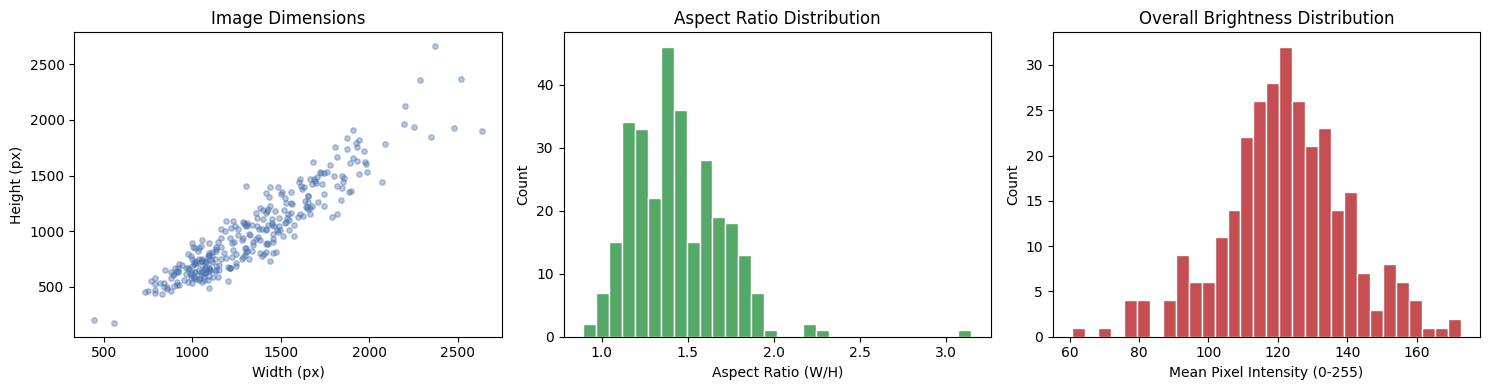

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(feat_df["width"], feat_df["height"], alpha=0.4, s=15, color="#4C72B0")
axes[0].set_xlabel("Width (px)")
axes[0].set_ylabel("Height (px)")
axes[0].set_title("Image Dimensions")

axes[1].hist(feat_df["aspect_ratio"], bins=30, color="#55A868", edgecolor="white")
axes[1].set_xlabel("Aspect Ratio (W/H)")
axes[1].set_ylabel("Count")
axes[1].set_title("Aspect Ratio Distribution")

axes[2].hist(feat_df["mean_pixel_intensity"], bins=30, color="#C44E52", edgecolor="white")
axes[2].set_xlabel("Mean Pixel Intensity (0-255)")
axes[2].set_ylabel("Count")
axes[2].set_title("Overall Brightness Distribution")

plt.tight_layout()
plt.savefig("image_feature_distributions.png", dpi=150)
plt.show()

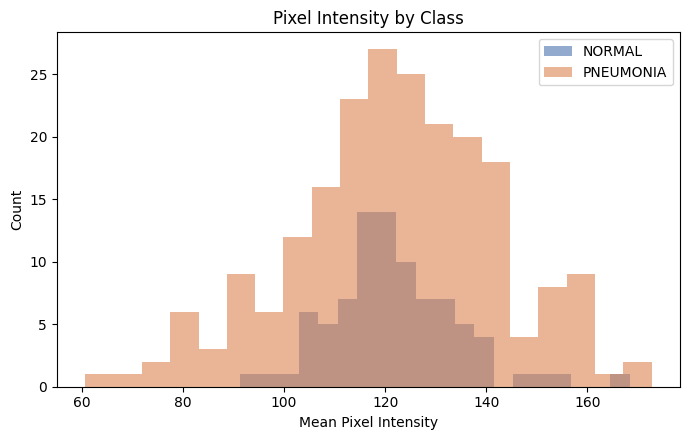

NORMAL    mean intensity: 121.77  (n=86)
PNEUMONIA mean intensity: 122.22  (n=214)

Pneumonia X-rays tend to show denser white/hazy consolidation regions,
which can shift overall image brightness statistics relative to clear,
mostly dark (air-filled) NORMAL lungs — useful context before modeling.


In [14]:
normal_intensities, pneumonia_intensities = [], []

for idx in indices:
    sample = dataset["train"][idx]
    arr = np.array(sample["image"].convert("L"), dtype=np.float32)
    if sample["label"] == 0:
        normal_intensities.append(arr.mean())
    else:
        pneumonia_intensities.append(arr.mean())

plt.figure(figsize=(7, 4.5))
plt.hist(normal_intensities, bins=20, alpha=0.6, label="NORMAL", color="#4C72B0")
plt.hist(pneumonia_intensities, bins=20, alpha=0.6, label="PNEUMONIA", color="#DD8452")
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Count")
plt.title("Pixel Intensity by Class")
plt.legend()
plt.tight_layout()
plt.savefig("intensity_by_class.png", dpi=150)
plt.show()

print(f"NORMAL    mean intensity: {np.mean(normal_intensities):.2f}  (n={len(normal_intensities)})")
print(f"PNEUMONIA mean intensity: {np.mean(pneumonia_intensities):.2f}  (n={len(pneumonia_intensities)})")
print()
print("Pneumonia X-rays tend to show denser white/hazy consolidation regions,")
print("which can shift overall image brightness statistics relative to clear,")
print("mostly dark (air-filled) NORMAL lungs — useful context before modeling.")

Train/Validation split

The official test split (624 images) is kept as the held-out test set. The HF validation split (16 images) is too small to be useful, so a stratified 15% validation set is carved out of the training split instead. Stratifying by `label` keeps the NORMAL/PNEUMONIA ratio (~26% / 74%) the same in train and validation. Class imbalance is handled later during training (e.g. class weights), not by the split.

In [15]:
VAL_FRACTION = 0.15
SEED = 42

# Stratify on label so NORMAL/PNEUMONIA proportions match across train and validation.
# The official HF test split (624) is kept untouched; the 16-image HF validation split is not used.
split = dataset["train"].train_test_split(
    test_size=VAL_FRACTION, seed=SEED, stratify_by_column="label"
)
train_final, val_final = split["train"], split["test"]
test_final = dataset["test"]

split_summary = pd.DataFrame({
    "split": ["train", "validation", "test"],
    "n_samples": [len(train_final), len(val_final), len(test_final)],
})
split_summary["pct_of_total"] = (
    split_summary["n_samples"] / split_summary["n_samples"].sum() * 100
).round(1)
split_summary

,split,n_samples,pct_of_total
0,train,4433,75.9
1,validation,783,13.4
2,test,624,10.7


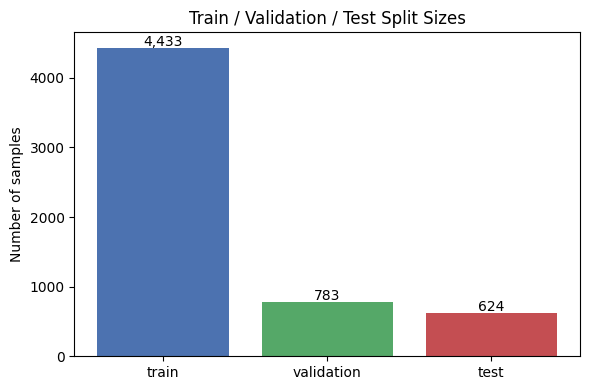

In [16]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(split_summary["split"], split_summary["n_samples"],
       color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylabel("Number of samples")
ax.set_title("Train / Validation / Test Split Sizes")
for i, v in enumerate(split_summary["n_samples"]):
    ax.text(i, v + 20, f"{v:,}", ha="center", fontsize=10)
plt.tight_layout()
plt.savefig("train_val_test_split.png", dpi=150)
plt.show()

In [17]:
def class_balance(split_ds, name):
    counts = Counter(split_ds["label"])
    names = dataset["train"].features["label"].names
    row = {names[k]: v for k, v in counts.items()}
    row["split"] = name
    return row

balance_df = pd.DataFrame([
    class_balance(train_final, "train"),
    class_balance(val_final, "validation"),
    class_balance(test_final, "test"),
]).set_index("split")
balance_df

,PNEUMONIA,NORMAL
split,,
train,3293,1140
validation,582,201
test,390,234


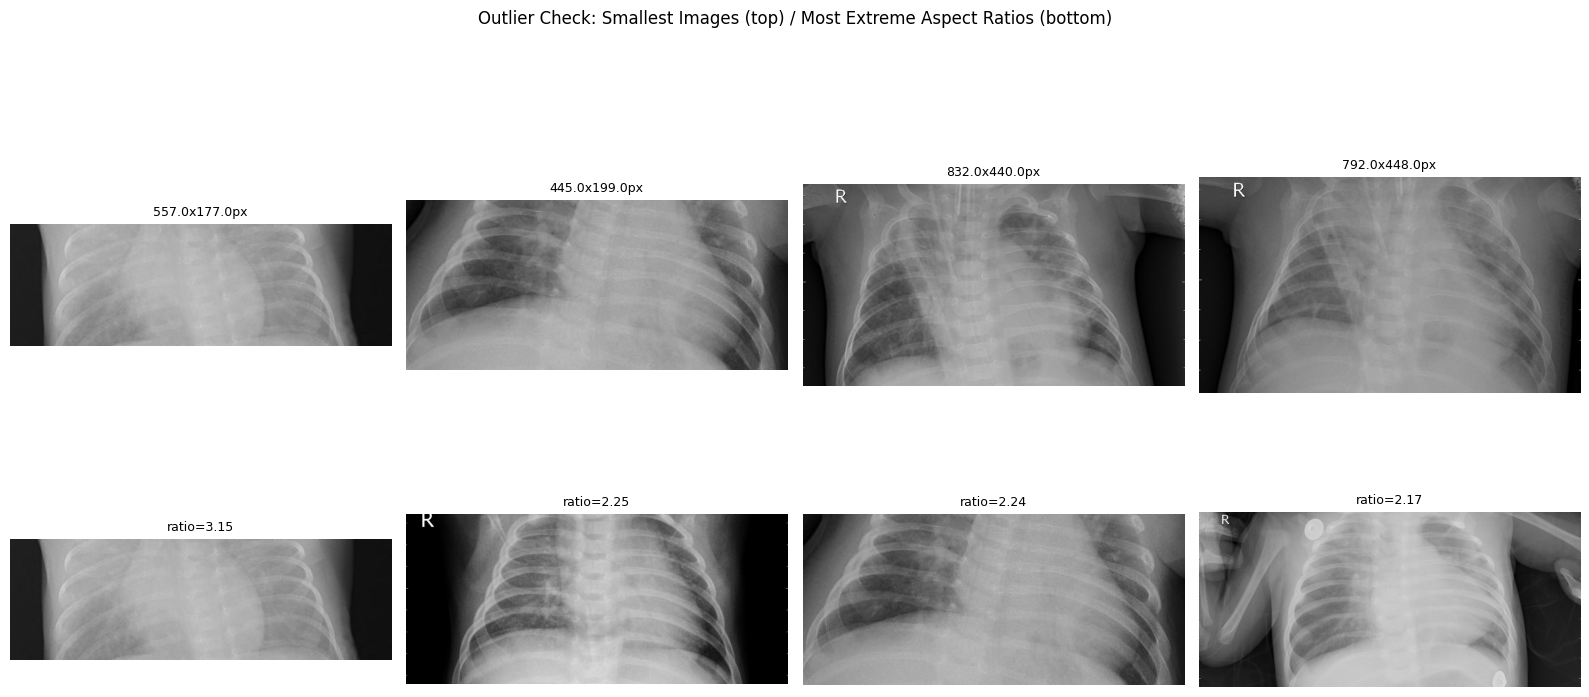

Review: do any of these look corrupted, mislabeled, or unusable (e.g. a
thumbnail, a cropped fragment, or a non-chest image)? If so, exclude them
before training rather than relying on resizing to mask the issue.


In [18]:
# Smallest images by height, and most extreme aspect ratios, from the
# 300-image sample gathered in Section 4.2

outlier_candidates = feat_df.copy()
outlier_candidates["orig_index"] = indices

smallest = outlier_candidates.nsmallest(4, "height")
most_extreme_ratio = outlier_candidates.iloc[
    (outlier_candidates["aspect_ratio"] - 1).abs().nlargest(4).index
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for col, (_, row) in enumerate(smallest.iterrows()):
    img = dataset["train"][int(row["orig_index"])]["image"]
    axes[0, col].imshow(img, cmap="gray")
    axes[0, col].set_title(f"{row['width']}x{row['height']}px", fontsize=9)
    axes[0, col].axis("off")
axes[0, 0].set_ylabel("Smallest", fontsize=11)

for col, (_, row) in enumerate(most_extreme_ratio.iterrows()):
    img = dataset["train"][int(row["orig_index"])]["image"]
    axes[1, col].imshow(img, cmap="gray")
    axes[1, col].set_title(f"ratio={row['aspect_ratio']:.2f}", fontsize=9)
    axes[1, col].axis("off")

plt.suptitle("Outlier Check: Smallest Images (top) / Most Extreme Aspect Ratios (bottom)", y=1.02)
plt.tight_layout()
plt.savefig("size_outliers.png", dpi=150, bbox_inches="tight")
plt.show()

print("Review: do any of these look corrupted, mislabeled, or unusable (e.g. a")
print("thumbnail, a cropped fragment, or a non-chest image)? If so, exclude them")
print("before training rather than relying on resizing to mask the issue.")

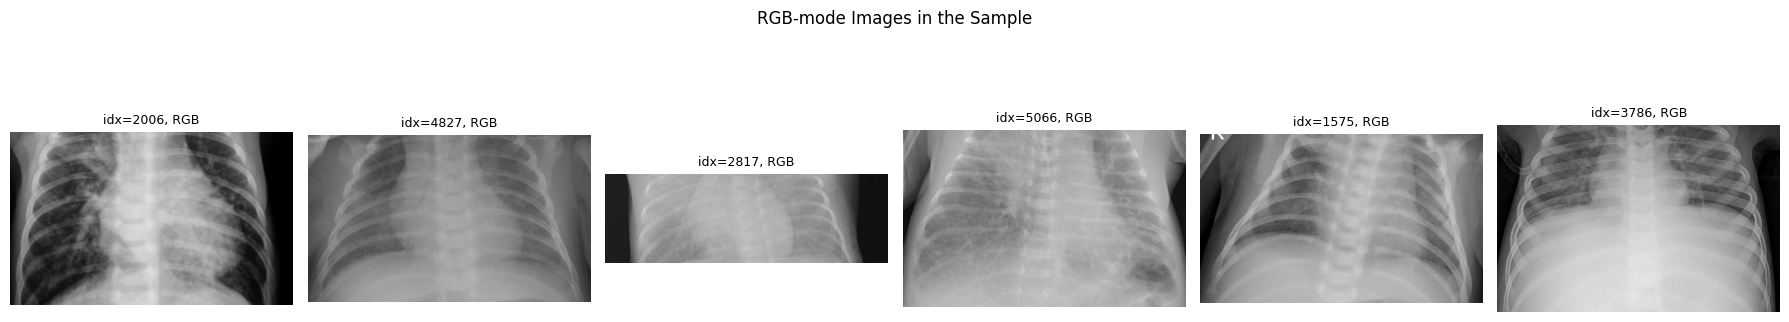

Found 15 RGB-mode images in the 300-image sample.
Visually: do these look like plain grayscale X-rays saved in RGB mode
(safe — .convert('L') in train.py handles this), or do they contain
actual color content/annotations (would need separate handling)?


In [19]:
# The sample in Section 4.2 found a mix of 'L' (grayscale) and 'RGB' images.
# Display the RGB ones specifically to check for burned-in annotations,
# borders, or color artifacts that grayscale conversion might not fully erase.

rgb_rows = [(idx, dataset["train"][idx]["image"]) for idx in indices
            if dataset["train"][idx]["image"].mode == "RGB"]

n_show = min(6, len(rgb_rows))
if n_show > 0:
    fig, axes = plt.subplots(1, n_show, figsize=(3 * n_show, 3.5))
    if n_show == 1:
        axes = [axes]
    for col, (idx, img) in enumerate(rgb_rows[:n_show]):
        axes[col].imshow(img)
        axes[col].set_title(f"idx={idx}, RGB", fontsize=9)
        axes[col].axis("off")
    plt.suptitle("RGB-mode Images in the Sample", y=1.05)
    plt.tight_layout()
    plt.savefig("rgb_spotcheck.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Found {len(rgb_rows)} RGB-mode images in the {SAMPLE_SIZE}-image sample.")
    print("Visually: do these look like plain grayscale X-rays saved in RGB mode")
    print("(safe — .convert('L') in train.py handles this), or do they contain")
    print("actual color content/annotations (would need separate handling)?")
else:
    print("No RGB-mode images in this sample.")

In [20]:
#this is to check for duplicate images that might be present

def average_hash(img, hash_size=8):
    small = img.convert("L").resize((hash_size, hash_size))
    arr = np.array(small, dtype=np.float32)
    avg = arr.mean()
    bits = (arr > avg).flatten()
    return "".join("1" if b else "0" for b in bits)

DUP_SAMPLE_SIZE = 500
random.seed(42)
train_check_idx = random.sample(range(len(dataset["train"])), min(DUP_SAMPLE_SIZE, len(dataset["train"])))
test_check_idx = random.sample(range(len(dataset["test"])), min(DUP_SAMPLE_SIZE, len(dataset["test"])))

train_hashes = {average_hash(dataset["train"][i]["image"]): ("train", i) for i in train_check_idx}
test_hashes = {average_hash(dataset["test"][i]["image"]): ("test", i) for i in test_check_idx}

overlap = set(train_hashes) & set(test_hashes)

print(f"Sampled {len(train_check_idx)} train images and {len(test_check_idx)} test images.")
print(f"Exact average-hash matches between train and test sample: {len(overlap)}")
if overlap:
    print("WARNING: possible train/test leakage — inspect these pairs before training.")
else:
    print("No exact-hash duplicates found between the sampled train and test images.")
    print("(Note: this is a sample-based check, not exhaustive over the full dataset,")
    print("and average-hash only catches near-identical images, not all forms of leakage.)")

Sampled 500 train images and 500 test images.
Exact average-hash matches between train and test sample: 8


test split sample images

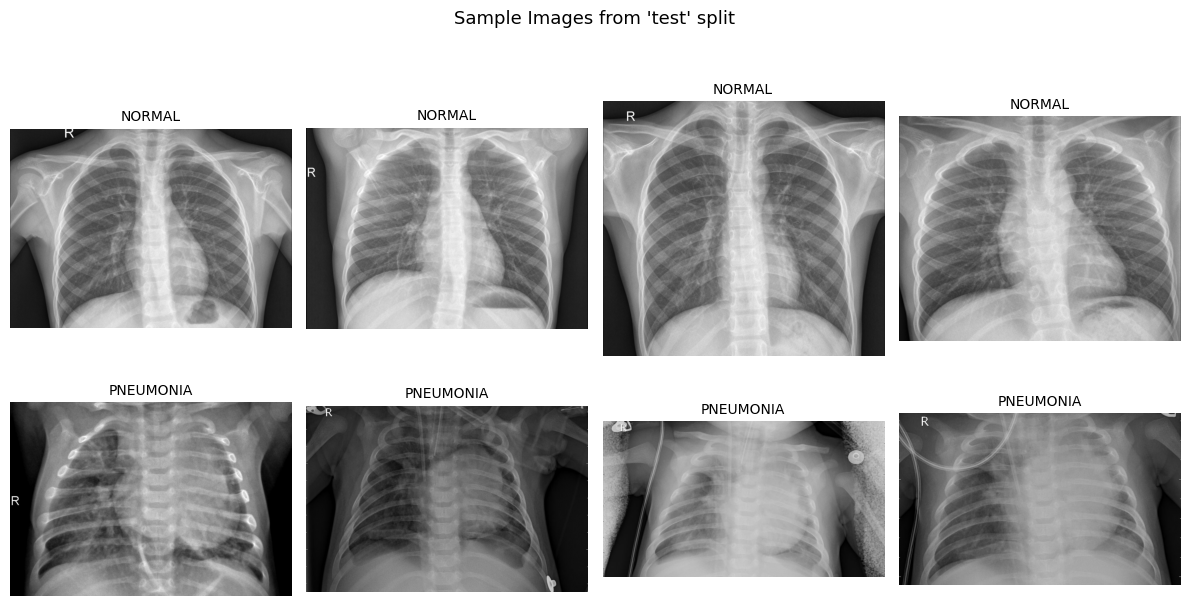

In [21]:
show_sample_grid("test", n_per_class=4)

In [22]:


def estimate_avg_bytes(split, n=50):
    total_bytes = 0
    idxs = random.sample(range(len(dataset[split])), n)
    for i in idxs:
        buf = io.BytesIO()
        dataset[split][i]["image"].save(buf, format="PNG")
        total_bytes += buf.tell()
    return total_bytes / n

avg_bytes_train = estimate_avg_bytes("train")
est_total_mb = avg_bytes_train * total / (1024 ** 2)

print(f"Estimated avg image size (re-encoded PNG): {avg_bytes_train / 1024:.1f} KB")
print(f"Estimated total dataset footprint         : {est_total_mb:,.0f} MB (rough estimate)")

Estimated avg image size (re-encoded PNG): 478.1 KB
Estimated total dataset footprint         : 2,727 MB (rough estimate)
